            # Experiment: CADICA Dataset EDA

            **Objective**
            - Build a reproducible, local EDA notebook for CADICA using the extracted dataset at `datasets/cadica/CADICA`.
            - Explain the storage hierarchy clearly enough for downstream preprocessing and modeling work.
            - Quantify patients, videos, frames, keyframes, annotations, and clinically relevant metadata.
            - Surface dataset tendencies, data-quality issues, and concrete leakage risks before training.
            


In [1]:
from __future__ import annotations

import hashlib
import json
import math
import re
import struct
import subprocess
import sys
import warnings
from collections import Counter
from pathlib import Path

def ensure_package(module_name: str, package_name: str | None = None) -> None:
    try:
        __import__(module_name)
    except ModuleNotFoundError:
        package = package_name or module_name
        print(f"Installing missing dependency: {package}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

ensure_package("openpyxl")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
from PIL import Image

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)


            ## Configuration And Notebook Map

            This notebook builds four reusable tables for later work:
            - `patient_df`: patient-level metadata plus dataset inventory
            - `video_df`: one row per video across `selectedVideos` and `nonselectedVideos`
            - `bbox_df`: one row per lesion annotation box
            - `consistency_df`: integrity and leakage-oriented checks

            All quantitative charts below use `seaborn`. Image thumbnails and bounding-box overlays use `matplotlib`, because those are inspection visuals rather than statistical charts.
            


In [2]:
DATASET_ROOT = Path("/Users/iwosmura/projects/angio-demo/Angiography/datasets/cadica/CADICA")
SELECTED_ROOT = DATASET_ROOT / "selectedVideos"
NONSELECTED_ROOT = DATASET_ROOT / "nonselectedVideos"
METADATA_PATH = DATASET_ROOT / "metadata.xlsx"
README_PATH = DATASET_ROOT / "readme.txt"
PROJECTION_PATH = SELECTED_ROOT / "CADICAprojections.json"
REPO_SPLIT_SCRIPT = Path("/Users/iwosmura/projects/angio-demo/Angiography/models/yolov8-stenosis/YOLOv8-stenosis/scripts/prepare_split.py")

FPS = 10
IMAGE_AREA = 512 * 512
EXPECTED_PATIENTS = 42
EXPECTED_SELECTED_VIDEOS = 382
EXPECTED_NONSELECTED_VIDEOS = 286
EXPECTED_TOTAL_PNGS = 31500
EXPECTED_LESION_VIDEOS = 269

DEGREE_ORDER = ["<20%", "20-50%", "50-70%", "70-90%", "90-98%", "99%", "100%"]
PROJECTION_ORDER = ["videosLCA", "videosLCA2", "videosRCA", "missing_projection", "not_applicable"]
BINARY_COLUMNS = [
    "Diabetes mellitus",
    "Dyslipidemia",
    "Smoker",
    "High blood pressure",
    "Kidney failure",
    "Heart failure",
    "Atrial fibrillation",
]

assert DATASET_ROOT.exists(), f"Dataset root not found: {DATASET_ROOT}"
assert SELECTED_ROOT.exists(), "selectedVideos folder is missing"
assert NONSELECTED_ROOT.exists(), "nonselectedVideos folder is missing"
assert METADATA_PATH.exists(), "metadata.xlsx is missing"
assert README_PATH.exists(), "readme.txt is missing"
assert PROJECTION_PATH.exists(), "CADICAprojections.json is missing"

readme_text = README_PATH.read_text(encoding="utf-8")
projections = json.loads(PROJECTION_PATH.read_text())
projection_lookup = {
    video_key: projection_group
    for projection_group, video_keys in projections.items()
    for video_key in video_keys
}

def strip_lines(path: Path) -> list[str]:
    return [line.strip() for line in path.read_text().splitlines() if line.strip()]

def natural_patient_key(patient_name: str) -> int:
    return int(patient_name.removeprefix("p"))

def natural_video_key(video_name: str) -> int:
    return int(video_name.removeprefix("v"))

def normalize_degree_label(value: object) -> str | pd.NA:
    if pd.isna(value):
        return pd.NA
    text = str(value).strip()
    if not text:
        return pd.NA
    text = re.sub(r"\s+", "", text)
    text = text.replace(">", ">").replace("<", "<")
    mapping = {
        "<20%": "<20%",
        "20-50%": "20-50%",
        "50-70%": "50-70%",
        "70-90%": "70-90%",
        "90-98%": "90-98%",
        "99%": "99%",
        "100%": "100%",
        ">70%": "70%+",
    }
    return mapping.get(text, text)

def normalize_clinical_indication(value: object) -> str | pd.NA:
    if pd.isna(value):
        return pd.NA
    text = str(value).strip()
    if not text:
        return pd.NA
    lowered = text.lower()
    lowered = lowered.replace("angiogrphy", "angiography")
    lowered = lowered.replace("st segment", "st-segment")
    lowered = lowered.replace("non-st segment", "non-st-segment")
    lowered = lowered.replace("non-st-segment elevation acute coronary syndrome", "non-st-segment elevation acute coronary syndrome")
    mapping = {
        "non-st-segment elevation acute coronary syndrome": "Non-ST-segment elevation acute coronary syndrome",
        "st-segment elevation acute coronary syndrome": "ST-segment elevation acute coronary syndrome",
        "stable angina": "Stable angina",
    }
    return mapping.get(lowered, text)

def read_png_size(path: Path) -> tuple[int, int]:
    with path.open("rb") as file_obj:
        header = file_obj.read(24)
    if header[:8] != b"\x89PNG\r\n\x1a\n":
        raise ValueError(f"Unexpected PNG signature: {path}")
    return struct.unpack(">II", header[16:24])

def load_metadata() -> pd.DataFrame:
    metadata = pd.read_excel(METADATA_PATH)
    metadata["patient_int"] = metadata["Patient ID"].astype(int)
    metadata["patient"] = "p" + metadata["patient_int"].astype(str)
    metadata["max_degree_raw"] = metadata["Maximum degree of the coronary artery involvement"].astype("string")
    metadata["max_degree_clean"] = metadata["max_degree_raw"].map(normalize_degree_label).astype("string")
    metadata["clinical_indication_raw"] = metadata["Clinical indication for angiogrphy"].astype("string")
    metadata["clinical_indication_clean"] = metadata["clinical_indication_raw"].map(normalize_clinical_indication).astype("string")
    metadata["Age (years)"] = pd.to_numeric(metadata["Age (years)"], errors="coerce")
    metadata["Height (m)"] = pd.to_numeric(metadata["Height (m)"], errors="coerce")
    metadata["Weight (kg)"] = pd.to_numeric(metadata["Weight (kg)"], errors="coerce")
    metadata["BMI"] = pd.to_numeric(metadata["BMI"], errors="coerce")
    metadata["Evolution diabetes (years)"] = pd.to_numeric(metadata["Evolution diabetes (years)"], errors="coerce")
    metadata["Number of vessels affected"] = pd.to_numeric(metadata["Number of vessels affected"], errors="coerce")
    for column in BINARY_COLUMNS:
        metadata[column] = pd.to_numeric(metadata[column], errors="coerce").astype("Int64")
    return metadata.sort_values("patient_int").reset_index(drop=True)

def build_tables() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    metadata = load_metadata()
    video_rows: list[dict] = []
    bbox_rows: list[dict] = []
    png_size_issues: list[dict] = []
    duplicate_hashes: dict[str, list[str]] = {}
    selected_keyframe_hash_rows: list[dict] = []

    selected_patient_folder_count = len(
        [patient for patient in SELECTED_ROOT.iterdir() if patient.is_dir() and patient.name.startswith("p")]
    )
    nonselected_patient_folder_count = len(
        [patient for patient in NONSELECTED_ROOT.iterdir() if patient.is_dir() and patient.name.startswith("p")]
    )

    all_patient_ids = sorted(
        {patient.name for patient in SELECTED_ROOT.iterdir() if patient.is_dir() and patient.name.startswith("p")},
        key=natural_patient_key,
    )
    assert all_patient_ids == [f"p{i}" for i in range(1, EXPECTED_PATIENTS + 1)]

    for split_name, split_root in [("selected", SELECTED_ROOT), ("nonselected", NONSELECTED_ROOT)]:
        patients = sorted(
            [patient for patient in split_root.iterdir() if patient.is_dir() and patient.name.startswith("p")],
            key=lambda path: natural_patient_key(path.name),
        )
        for patient_dir in patients:
            lesion_videos = set(strip_lines(patient_dir / "lesionVideos.txt")) if split_name == "selected" else set()
            nonlesion_videos = set(strip_lines(patient_dir / "nonlesionVideos.txt")) if split_name == "selected" else set()
            videos = sorted(
                [video for video in patient_dir.iterdir() if video.is_dir() and video.name.startswith("v")],
                key=lambda path: natural_video_key(path.name),
            )

            for video_dir in videos:
                input_dir = video_dir / "input"
                frame_paths = sorted(input_dir.glob("*.png"))
                selected_frames_path = next(video_dir.glob("*_selectedFrames.txt"), None)
                selected_frame_ids = strip_lines(selected_frames_path) if selected_frames_path else []
                keyframe_paths = [input_dir / f"{frame_id}.png" for frame_id in selected_frame_ids]
                gt_dir = video_dir / "groundtruth"
                gt_txt_paths = sorted(
                    [
                        path
                        for path in gt_dir.glob("*.txt")
                        if "groundTruthTable" not in path.name
                    ]
                ) if gt_dir.exists() else []

                for frame_path in frame_paths:
                    width, height = read_png_size(frame_path)
                    if (width, height) != (512, 512):
                        png_size_issues.append(
                            {
                                "split_name": split_name,
                                "patient": patient_dir.name,
                                "video": video_dir.name,
                                "frame_path": str(frame_path),
                                "width": width,
                                "height": height,
                            }
                        )

                lesion_flag = video_dir.name in lesion_videos
                nonlesion_flag = video_dir.name in nonlesion_videos

                if split_name == "selected":
                    assert lesion_flag ^ nonlesion_flag, f"Selected video missing lesion state: {video_dir}"
                else:
                    assert not gt_dir.exists(), f"nonselected video should not have ground truth: {video_dir}"

                video_key = f"{patient_dir.name}_{video_dir.name}"
                video_rows.append(
                    {
                        "split_name": split_name,
                        "patient": patient_dir.name,
                        "patient_int": natural_patient_key(patient_dir.name),
                        "video": video_dir.name,
                        "video_int": natural_video_key(video_dir.name),
                        "video_key": video_key,
                        "is_selected_split": split_name == "selected",
                        "lesion_flag": lesion_flag,
                        "nonlesion_flag": nonlesion_flag,
                        "has_groundtruth": gt_dir.exists(),
                        "frame_count": len(frame_paths),
                        "keyframe_count": len(selected_frame_ids),
                        "keyframe_ratio": (len(selected_frame_ids) / len(frame_paths)) if frame_paths else np.nan,
                        "implied_duration_seconds": len(frame_paths) / FPS if frame_paths else np.nan,
                        "projection_group": projection_lookup.get(video_key, "missing_projection") if split_name == "selected" else "not_applicable",
                        "selected_frames_path": str(selected_frames_path) if selected_frames_path else None,
                        "groundtruth_dir": str(gt_dir) if gt_dir.exists() else None,
                    }
                )

                if split_name == "selected":
                    gt_frame_ids = {path.stem for path in gt_txt_paths}
                    assert gt_frame_ids.issubset(set(selected_frame_ids)), f"Ground truth frames not included in selected frames: {video_dir}"
                    if lesion_flag:
                        assert gt_dir.exists(), f"Lesion video is missing ground truth: {video_dir}"
                    if gt_dir.exists():
                        for gt_path in gt_txt_paths:
                            for line in gt_path.read_text().splitlines():
                                line = line.strip()
                                if not line:
                                    continue
                                x, y, w, h, severity = line.split()
                                x_f, y_f, w_f, h_f = map(float, (x, y, w, h))
                                bbox_rows.append(
                                    {
                                        "patient": patient_dir.name,
                                        "patient_int": natural_patient_key(patient_dir.name),
                                        "video": video_dir.name,
                                        "video_key": video_key,
                                        "frame_id": gt_path.stem,
                                        "severity_class": severity,
                                        "x": x_f,
                                        "y": y_f,
                                        "width": w_f,
                                        "height": h_f,
                                        "area_px": w_f * h_f,
                                        "area_ratio": (w_f * h_f) / IMAGE_AREA,
                                        "area_pct": 100 * (w_f * h_f) / IMAGE_AREA,
                                        "projection_group": projection_lookup.get(video_key, "missing_projection"),
                                    }
                                )

                    for frame_path in keyframe_paths:
                        digest = hashlib.md5(frame_path.read_bytes()).hexdigest()
                        selected_keyframe_hash_rows.append(
                            {
                                "patient": patient_dir.name,
                                "video": video_dir.name,
                                "video_key": video_key,
                                "frame_path": str(frame_path),
                                "frame_name": frame_path.name,
                                "md5": digest,
                            }
                        )

    metadata_df = metadata.copy()
    video_df = pd.DataFrame(video_rows).sort_values(["split_name", "patient_int", "video_int"]).reset_index(drop=True)
    bbox_df = pd.DataFrame(bbox_rows).sort_values(["patient_int", "video", "frame_id"]).reset_index(drop=True)
    keyframe_hash_df = pd.DataFrame(selected_keyframe_hash_rows)

    video_df["selected_video_indicator"] = (video_df["split_name"] == "selected").astype(int)
    video_df["nonselected_video_indicator"] = (video_df["split_name"] == "nonselected").astype(int)
    video_df["selected_frame_contrib"] = np.where(video_df["split_name"] == "selected", video_df["frame_count"], 0)
    video_df["nonselected_frame_contrib"] = np.where(video_df["split_name"] == "nonselected", video_df["frame_count"], 0)

    patient_inventory = (
        video_df.groupby("patient", as_index=False)
        .agg(
            total_videos=("video_key", "count"),
            selected_video_count=("selected_video_indicator", "sum"),
            nonselected_video_count=("nonselected_video_indicator", "sum"),
            selected_lesion_video_count=("lesion_flag", "sum"),
            selected_nonlesion_video_count=("nonlesion_flag", "sum"),
            total_frames=("frame_count", "sum"),
            selected_frames=("selected_frame_contrib", "sum"),
            nonselected_frames=("nonselected_frame_contrib", "sum"),
            projection_group_count=("projection_group", lambda values: len({value for value in values if value not in {"not_applicable", "missing_projection"}})),
        )
    )
    patient_inventory["patient_int"] = patient_inventory["patient"].str.removeprefix("p").astype(int)
    patient_inventory["has_both_lesion_and_nonlesion_selected"] = (
        (patient_inventory["selected_lesion_video_count"] > 0)
        & (patient_inventory["selected_nonlesion_video_count"] > 0)
    )
    patient_inventory["has_selected_and_nonselected"] = (
        (patient_inventory["selected_video_count"] > 0)
        & (patient_inventory["nonselected_video_count"] > 0)
    )

    patient_df = (
        metadata_df.merge(patient_inventory, on=["patient", "patient_int"], how="left")
        .sort_values("patient_int")
        .reset_index(drop=True)
    )

    selected_same_id_overlap = []
    for patient_name in patient_df["patient"]:
        selected_ids = set(
            video_df.loc[(video_df["patient"] == patient_name) & (video_df["split_name"] == "selected"), "video"]
        )
        nonselected_ids = set(
            video_df.loc[(video_df["patient"] == patient_name) & (video_df["split_name"] == "nonselected"), "video"]
        )
        overlap = selected_ids & nonselected_ids
        if overlap:
            selected_same_id_overlap.append((patient_name, sorted(overlap)))

    duplicate_groups = []
    if not keyframe_hash_df.empty:
        for digest, group in keyframe_hash_df.groupby("md5"):
            if len(group) > 1:
                duplicate_groups.append(
                    {
                        "md5": digest,
                        "occurrences": len(group),
                        "unique_videos": group["video_key"].nunique(),
                        "unique_patients": group["patient"].nunique(),
                        "frame_paths": " | ".join(group["frame_path"].tolist()),
                    }
                )
    if duplicate_groups:
        duplicate_df = pd.DataFrame(duplicate_groups).sort_values(["occurrences", "unique_videos"], ascending=[False, False]).reset_index(drop=True)
    else:
        duplicate_df = pd.DataFrame(columns=["md5", "occurrences", "unique_videos", "unique_patients", "frame_paths"])

    selection_projection_counts = (
        video_df.loc[video_df["split_name"] == "selected", "projection_group"]
        .value_counts()
        .rename_axis("projection_group")
        .reset_index(name="video_count")
    )

    consistency_rows = [
        {
            "check": "selected patient folders",
            "status": "pass" if selected_patient_folder_count == EXPECTED_PATIENTS else "fail",
            "value": int(selected_patient_folder_count),
            "details": "Expected 42 patient folders in selectedVideos.",
        },
        {
            "check": "nonselected patient folders",
            "status": "pass" if nonselected_patient_folder_count == EXPECTED_PATIENTS else "fail",
            "value": int(nonselected_patient_folder_count),
            "details": "All 42 patient folders exist in nonselectedVideos, although only 36 contain at least one nonselected video.",
        },
        {
            "check": "selected videos",
            "status": "pass" if int((video_df["split_name"] == "selected").sum()) == EXPECTED_SELECTED_VIDEOS else "fail",
            "value": int((video_df["split_name"] == "selected").sum()),
            "details": "Expected 382 selected videos.",
        },
        {
            "check": "nonselected videos",
            "status": "pass" if int((video_df["split_name"] == "nonselected").sum()) == EXPECTED_NONSELECTED_VIDEOS else "fail",
            "value": int((video_df["split_name"] == "nonselected").sum()),
            "details": "Expected 286 nonselected videos.",
        },
        {
            "check": "lesion videos with ground truth",
            "status": "pass" if int(video_df["has_groundtruth"].sum()) == EXPECTED_LESION_VIDEOS else "fail",
            "value": int(video_df["has_groundtruth"].sum()),
            "details": "Expected 269 lesion videos with annotation folders.",
        },
        {
            "check": "all PNGs are 512x512",
            "status": "pass" if not png_size_issues else "fail",
            "value": int(video_df["frame_count"].sum()),
            "details": "All 31,500 PNG files were checked via the PNG header.",
        },
        {
            "check": "patient ids are contiguous",
            "status": "pass",
            "value": "p1-p42",
            "details": "Selected split contains exactly p1 through p42.",
        },
        {
            "check": "ground truth only appears in lesion videos",
            "status": "pass" if bool((video_df["has_groundtruth"] == video_df["lesion_flag"]).loc[video_df["split_name"] == "selected"].all()) else "fail",
            "value": int(video_df.loc[video_df["split_name"] == "selected", "has_groundtruth"].sum()),
            "details": "Every lesion video has a groundtruth directory and no non-lesion selected video does.",
        },
        {
            "check": "ground truth frames are a subset of selected frames",
            "status": "pass",
            "value": int(bbox_df["frame_id"].nunique()),
            "details": "Verified during table construction for every lesion video.",
        },
        {
            "check": "selected/nonselected video ids overlap within patient",
            "status": "pass" if not selected_same_id_overlap else "fail",
            "value": len(selected_same_id_overlap),
            "details": "No patient reuses the same v-id in both selected and nonselected folders.",
        },
        {
            "check": "projection json coverage",
            "status": "warning" if int((video_df["projection_group"] == "missing_projection").sum()) else "pass",
            "value": int((video_df["projection_group"] == "missing_projection").sum()),
            "details": "16 selected videos are not mapped in CADICAprojections.json.",
        },
        {
            "check": "exact duplicate selected keyframes",
            "status": "warning" if not duplicate_df.empty else "pass",
            "value": int(duplicate_df["occurrences"].sum()) if not duplicate_df.empty else 0,
            "details": "One duplicate hash group was found and it stays inside a single video (p25_v6).",
        },
    ]
    consistency_df = pd.DataFrame(consistency_rows)

    assert int(video_df["frame_count"].sum()) == EXPECTED_TOTAL_PNGS, "Unexpected total number of PNG frames"
    assert int((video_df["split_name"] == "selected").sum()) == EXPECTED_SELECTED_VIDEOS, "Unexpected selected video count"
    assert int((video_df["split_name"] == "nonselected").sum()) == EXPECTED_NONSELECTED_VIDEOS, "Unexpected nonselected video count"
    assert int(video_df["has_groundtruth"].sum()) == EXPECTED_LESION_VIDEOS, "Unexpected lesion video count"
    assert video_df.loc[video_df["split_name"] == "selected", "patient"].nunique() == EXPECTED_PATIENTS
    assert not png_size_issues, "Found PNG files with unexpected size"

    return patient_df, video_df, bbox_df, consistency_df, duplicate_df

patient_df, video_df, bbox_df, consistency_df, duplicate_df = build_tables()

overview_df = pd.DataFrame(
    [
        {"metric": "Patients", "value": patient_df["patient"].nunique()},
        {"metric": "Selected videos", "value": int((video_df["split_name"] == "selected").sum())},
        {"metric": "Nonselected videos", "value": int((video_df["split_name"] == "nonselected").sum())},
        {"metric": "Total PNG frames", "value": int(video_df["frame_count"].sum())},
        {"metric": "Lesion videos", "value": int(video_df["lesion_flag"].sum())},
        {"metric": "Annotated frames", "value": int(bbox_df["frame_id"].nunique())},
        {"metric": "Bounding boxes", "value": len(bbox_df)},
    ]
)

display(overview_df)
display(consistency_df)


,metric,value
0,Patients,42
1,Selected videos,382
2,Nonselected videos,286
3,Total PNG frames,31500
4,Lesion videos,269
5,Annotated frames,3996
6,Bounding boxes,6161


,check,status,value,details
0,selected patient folders,pass,42,Expected 42 patient folders in selectedVideos.
1,nonselected patient folders,pass,42,All 42 patient folders exist in nonselectedVid...
2,selected videos,pass,382,Expected 382 selected videos.
3,nonselected videos,pass,286,Expected 286 nonselected videos.
4,lesion videos with ground truth,pass,269,Expected 269 lesion videos with annotation fol...
5,all PNGs are 512x512,pass,31500,"All 31,500 PNG files were checked via the PNG ..."
6,patient ids are contiguous,pass,p1-p42,Selected split contains exactly p1 through p42.
7,ground truth only appears in lesion videos,pass,269,Every lesion video has a groundtruth directory...
8,ground truth frames are a subset of selected f...,pass,3996,Verified during table construction for every l...
9,selected/nonselected video ids overlap within ...,pass,0,No patient reuses the same v-id in both select...


            ## Visual Explanation Of The Dataset Structure

            The local CADICA copy is **patient-indexed and video-derived**:
            - The dataset is organized first by split-like curation bucket: `selectedVideos` and `nonselectedVideos`.
            - Inside each bucket, every patient has a `pX` folder and each angiography acquisition appears as a `vY` folder.
            - The stored media are not raw video files. Instead, every video is exported into a sequence of 512x512 PNG frames.
            - In `selectedVideos`, clinicians also provide a keyframe list per video and lesion videos include a `groundtruth` folder with bounding boxes.
            - In `nonselectedVideos`, only the extracted PNG frames are present, so these are useful for understanding coverage but not for box-level supervision.

            According to the CADICA dataset documentation and paper, the source angiograms were collected as DICOM video at 10 fps. The local release used here stores those videos as extracted PNG frame sequences, which is why the analysis below treats videos as frame folders plus metadata rather than `.mp4` or `.avi` files.
            


In [3]:
structure_df = pd.DataFrame(
    [
        {
            "level": "Split bucket",
            "example": "selectedVideos / nonselectedVideos",
            "contents": "Two top-level collections that separate medically selected videos from nonselected ones.",
        },
        {
            "level": "Patient folder",
            "example": "p17",
            "contents": "All videos for one patient plus lesion/non-lesion lists for the selected split.",
        },
        {
            "level": "Video folder",
            "example": "p17/v13",
            "contents": "One angiography run represented as a folder of extracted PNG frames.",
        },
        {
            "level": "Frame storage",
            "example": "input/p17_v13_00024.png",
            "contents": "One PNG per frame. These are the actual image files used for analysis.",
        },
        {
            "level": "Keyframe list",
            "example": "p17_v13_selectedFrames.txt",
            "contents": "Frame IDs selected by clinicians in `selectedVideos` only.",
        },
        {
            "level": "Ground truth",
            "example": "groundtruth/p17_v13_00024.txt",
            "contents": "Bounding boxes plus stenosis severity category, available only for lesion videos.",
        },
    ]
)

display(structure_df)

tree_text = """CADICA/
|- metadata.xlsx
|- readme.txt
|- selectedVideos/
|  |- CADICAprojections.json
|  |- pX/
|  |  |- lesionVideos.txt
|  |  |- nonlesionVideos.txt
|  |  |- vY/
|  |  |  |- input/
|  |  |  |  |- pX_vY_00001.png
|  |  |  |- pX_vY_selectedFrames.txt
|  |  |  |- groundtruth/        # lesion videos only
|  |  |     |- pX_vY_00015.txt
|  |  |     |- pX_vY_groundTruthTable.mat
|- nonselectedVideos/
   |- pX/
      |- vY/
         |- input/
            |- pX_vY_00001.png"""

display(Markdown(f"```text\n{tree_text}\n```"))


,level,example,contents
0,Split bucket,selectedVideos / nonselectedVideos,Two top-level collections that separate medica...
1,Patient folder,p17,All videos for one patient plus lesion/non-les...
2,Video folder,p17/v13,One angiography run represented as a folder of...
3,Frame storage,input/p17_v13_00024.png,One PNG per frame. These are the actual image ...
4,Keyframe list,p17_v13_selectedFrames.txt,Frame IDs selected by clinicians in `selectedV...
5,Ground truth,groundtruth/p17_v13_00024.txt,Bounding boxes plus stenosis severity category...


```text
CADICA/
|- metadata.xlsx
|- readme.txt
|- selectedVideos/
|  |- CADICAprojections.json
|  |- pX/
|  |  |- lesionVideos.txt
|  |  |- nonlesionVideos.txt
|  |  |- vY/
|  |  |  |- input/
|  |  |  |  |- pX_vY_00001.png
|  |  |  |- pX_vY_selectedFrames.txt
|  |  |  |- groundtruth/        # lesion videos only
|  |  |     |- pX_vY_00015.txt
|  |  |     |- pX_vY_groundTruthTable.mat
|- nonselectedVideos/
   |- pX/
      |- vY/
         |- input/
            |- pX_vY_00001.png
```

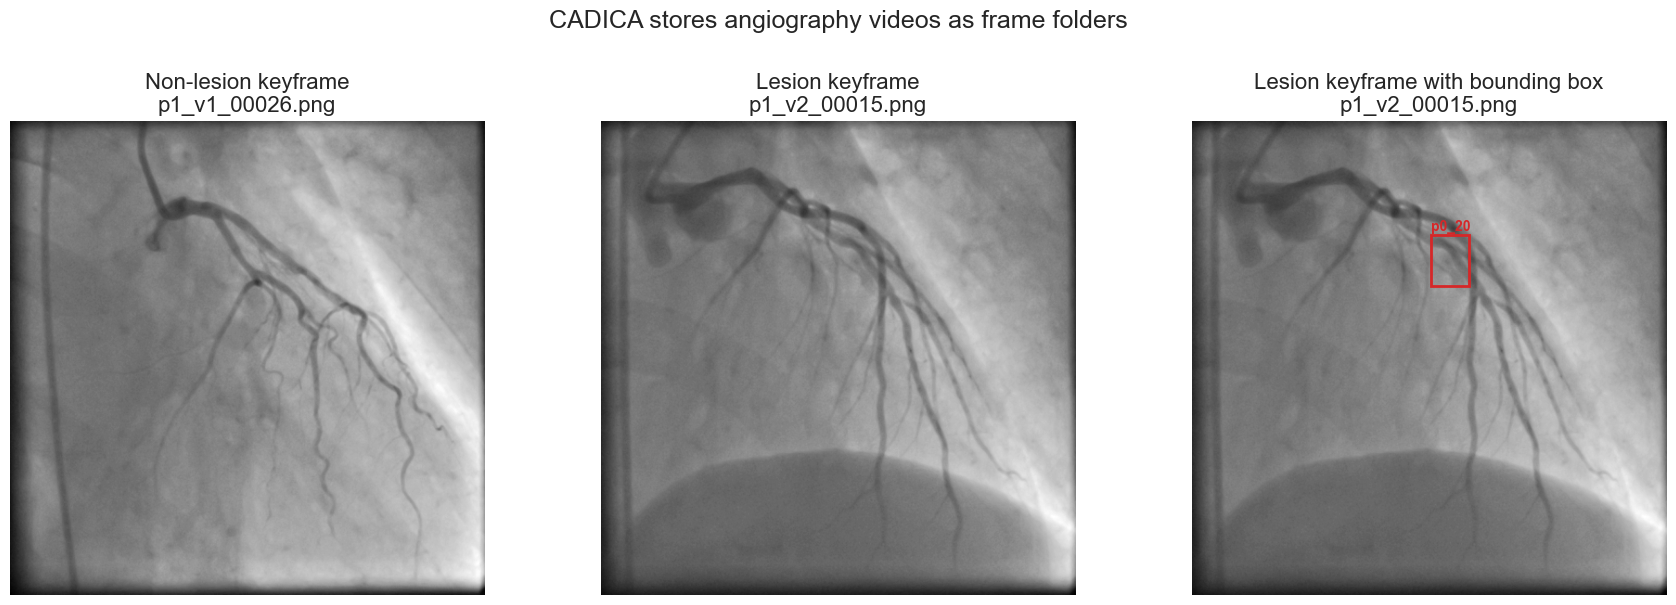

In [4]:
def first_selected_frame(video_row: pd.Series) -> tuple[Path, str]:
    video_dir = (SELECTED_ROOT if video_row["split_name"] == "selected" else NONSELECTED_ROOT) / video_row["patient"] / video_row["video"]
    if video_row["selected_frames_path"]:
        frame_ids = strip_lines(Path(video_row["selected_frames_path"]))
        if frame_ids:
            return video_dir / "input" / f"{frame_ids[0]}.png", frame_ids[0]
    frame_path = sorted((video_dir / "input").glob("*.png"))[0]
    return frame_path, frame_path.stem

lesion_sample = video_df.query("split_name == 'selected' and lesion_flag").sort_values(["patient_int", "video_int"]).iloc[0]
nonlesion_sample = video_df.query("split_name == 'selected' and nonlesion_flag").sort_values(["patient_int", "video_int"]).iloc[0]

nonlesion_frame_path, nonlesion_frame_id = first_selected_frame(nonlesion_sample)
lesion_frame_id = (
    bbox_df.loc[
        (bbox_df["patient"] == lesion_sample["patient"])
        & (bbox_df["video"] == lesion_sample["video"]),
        "frame_id",
    ]
    .sort_values()
    .iloc[0]
)
lesion_frame_path = SELECTED_ROOT / lesion_sample["patient"] / lesion_sample["video"] / "input" / f"{lesion_frame_id}.png"

lesion_boxes = bbox_df.loc[
    (bbox_df["patient"] == lesion_sample["patient"])
    & (bbox_df["video"] == lesion_sample["video"])
    & (bbox_df["frame_id"] == lesion_frame_id)
].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

nonlesion_img = np.array(Image.open(nonlesion_frame_path))
axes[0].imshow(nonlesion_img, cmap="gray")
axes[0].set_title(f"Non-lesion keyframe\n{nonlesion_frame_path.name}")
axes[0].axis("off")

lesion_img = np.array(Image.open(lesion_frame_path))
axes[1].imshow(lesion_img, cmap="gray")
axes[1].set_title(f"Lesion keyframe\n{lesion_frame_path.name}")
axes[1].axis("off")

axes[2].imshow(lesion_img, cmap="gray")
for _, row in lesion_boxes.iterrows():
    rect = Rectangle((row["x"], row["y"]), row["width"], row["height"], fill=False, edgecolor="#d62728", linewidth=2)
    axes[2].add_patch(rect)
    axes[2].text(row["x"], max(5, row["y"] - 4), row["severity_class"], color="#d62728", fontsize=10, weight="bold")
axes[2].set_title(f"Lesion keyframe with bounding box\n{lesion_frame_path.name}")
axes[2].axis("off")

fig.suptitle("CADICA stores angiography videos as frame folders", y=1.02, fontsize=18)
plt.tight_layout()
plt.show()


            ## How Much Data Is There?

            The local copy matches the expected high-level CADICA inventory:
            - 42 patients
            - 382 medically selected videos
            - 286 nonselected videos
            - 31,500 extracted PNG frames
            - 269 lesion videos with ground-truth annotations
            - 3,996 annotated frames and 6,161 bounding boxes

            The plots below break that down by patient, video, projection group, and frame density.
            


In [5]:
inventory_by_split = (
    video_df.groupby("split_name", as_index=False)
    .agg(
        patients=("patient", "nunique"),
        videos=("video_key", "count"),
        frames=("frame_count", "sum"),
        lesion_videos=("lesion_flag", "sum"),
        keyframes=("keyframe_count", "sum"),
    )
)
inventory_by_split


,split_name,patients,videos,frames,lesion_videos,keyframes
0,nonselected,36,286,13346,0,0
1,selected,42,382,18154,269,6126


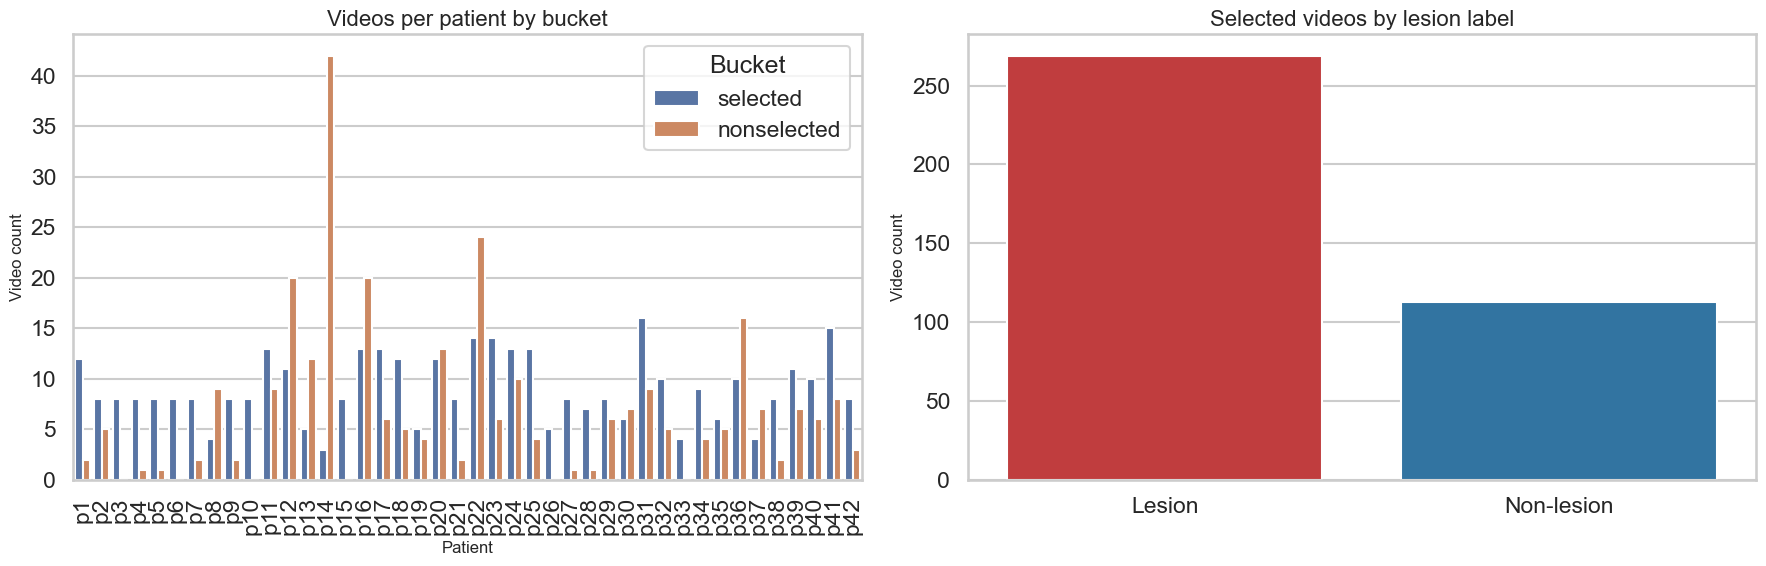

In [6]:
patient_video_counts = (
    patient_df[["patient", "selected_video_count", "nonselected_video_count"]]
    .melt(id_vars="patient", var_name="video_bucket", value_name="video_count")
    .assign(video_bucket=lambda frame: frame["video_bucket"].str.replace("_video_count", "", regex=False).str.replace("_", " "))
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=patient_video_counts,
    x="patient",
    y="video_count",
    hue="video_bucket",
    ax=axes[0],
)
axes[0].set_title("Videos per patient by bucket")
axes[0].set_xlabel("Patient")
axes[0].set_ylabel("Video count")
axes[0].tick_params(axis="x", rotation=90)
axes[0].legend(title="Bucket")

selected_label_counts = (
    video_df.query("split_name == 'selected'")
    .assign(label=lambda frame: np.where(frame["lesion_flag"], "Lesion", "Non-lesion"))
    .groupby("label", as_index=False)
    .size()
)
sns.barplot(data=selected_label_counts, x="label", y="size", palette=["#d62728", "#1f77b4"], ax=axes[1])
axes[1].set_title("Selected videos by lesion label")
axes[1].set_xlabel("")
axes[1].set_ylabel("Video count")

plt.tight_layout()
plt.show()


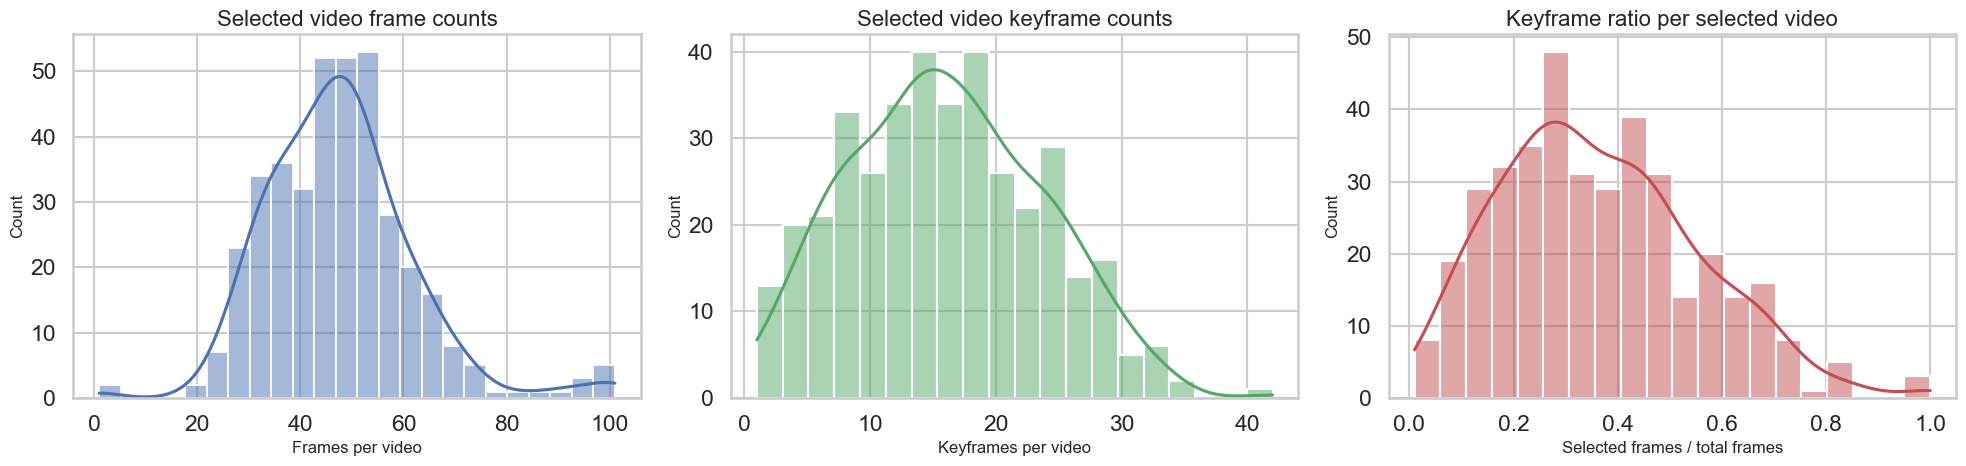

,count,mean,std,min,25%,50%,75%,max
frame_count,382.0,47.523560,14.370362,1.000000,38.000000,47.000000,55.000000,101.0
keyframe_count,382.0,16.036649,7.599815,1.000000,10.000000,16.000000,21.000000,42.0
keyframe_ratio,382.0,0.363554,0.189985,0.009901,0.229508,0.333333,0.481799,1.0
implied_duration_seconds,382.0,4.752356,1.437036,0.100000,3.800000,4.700000,5.500000,10.1


In [7]:
selected_video_df = video_df.query("split_name == 'selected'").copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.histplot(data=selected_video_df, x="frame_count", bins=24, kde=True, ax=axes[0], color="#4c72b0")
axes[0].set_title("Selected video frame counts")
axes[0].set_xlabel("Frames per video")

sns.histplot(data=selected_video_df, x="keyframe_count", bins=20, kde=True, ax=axes[1], color="#55a868")
axes[1].set_title("Selected video keyframe counts")
axes[1].set_xlabel("Keyframes per video")

sns.histplot(data=selected_video_df, x="keyframe_ratio", bins=20, kde=True, ax=axes[2], color="#c44e52")
axes[2].set_title("Keyframe ratio per selected video")
axes[2].set_xlabel("Selected frames / total frames")

plt.tight_layout()
plt.show()

selected_video_df[["frame_count", "keyframe_count", "keyframe_ratio", "implied_duration_seconds"]].describe().T


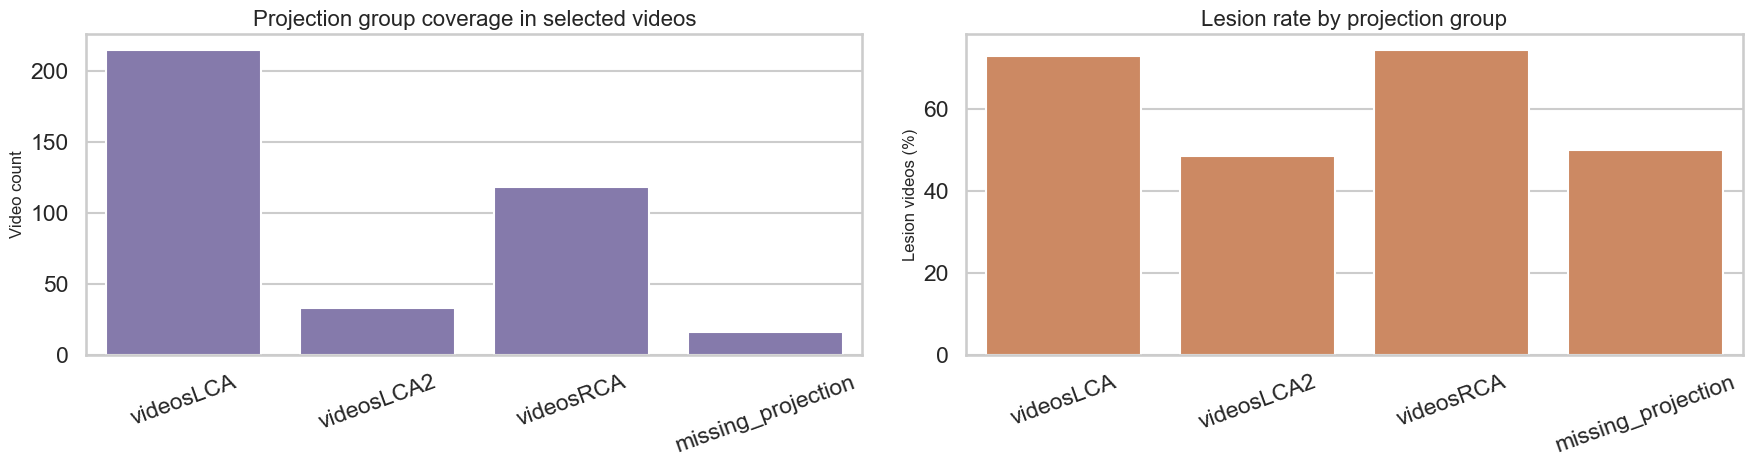

,projection_group,video_count,lesion_rate,lesion_rate_pct
1,videosLCA,215,0.730233,73.023256
2,videosLCA2,33,0.484848,48.484848
3,videosRCA,118,0.745763,74.576271
0,missing_projection,16,0.500000,50.000000


In [8]:
projection_summary = (
    selected_video_df.groupby("projection_group", as_index=False)
    .agg(video_count=("video_key", "count"), lesion_rate=("lesion_flag", "mean"))
)
projection_summary["lesion_rate_pct"] = 100 * projection_summary["lesion_rate"]
projection_summary = projection_summary.sort_values(
    "projection_group",
    key=lambda series: series.map({name: idx for idx, name in enumerate(PROJECTION_ORDER)}),
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.barplot(data=projection_summary, x="projection_group", y="video_count", ax=axes[0], color="#8172b3")
axes[0].set_title("Projection group coverage in selected videos")
axes[0].set_xlabel("")
axes[0].set_ylabel("Video count")

sns.barplot(data=projection_summary, x="projection_group", y="lesion_rate_pct", ax=axes[1], color="#dd8452")
axes[1].set_title("Lesion rate by projection group")
axes[1].set_xlabel("")
axes[1].set_ylabel("Lesion videos (%)")

for axis in axes:
    axis.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

projection_summary


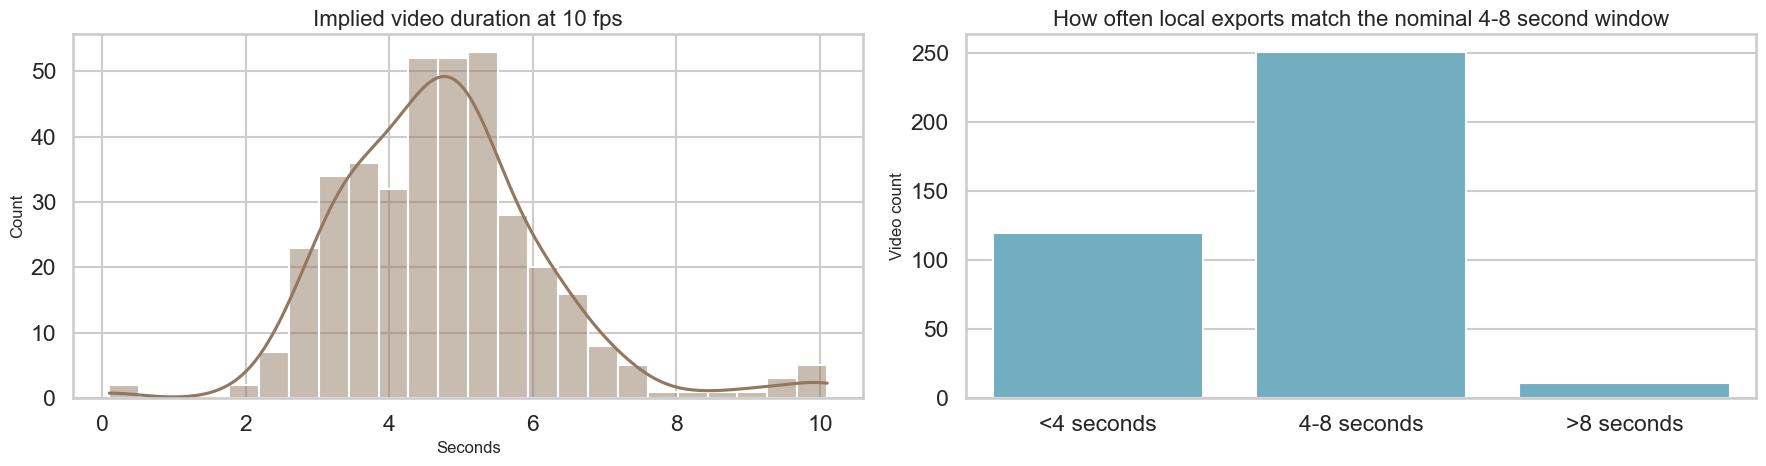

At 10 fps, the local export spans 0.1 to 10.1 seconds. Most selected videos fall inside 4-8 seconds, but there are shorter and longer exports too.


In [9]:
duration_note_df = selected_video_df.assign(
    duration_bucket=pd.cut(
        selected_video_df["implied_duration_seconds"],
        bins=[0, 4, 8, np.inf],
        labels=["<4 seconds", "4-8 seconds", ">8 seconds"],
        include_lowest=True,
    )
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(data=selected_video_df, x="implied_duration_seconds", bins=24, kde=True, ax=axes[0], color="#937860")
axes[0].set_title("Implied video duration at 10 fps")
axes[0].set_xlabel("Seconds")

bucket_counts = duration_note_df["duration_bucket"].value_counts(dropna=False).rename_axis("duration_bucket").reset_index(name="video_count")
sns.barplot(data=bucket_counts, x="duration_bucket", y="video_count", ax=axes[1], color="#64b5cd")
axes[1].set_title("How often local exports match the nominal 4-8 second window")
axes[1].set_xlabel("")
axes[1].set_ylabel("Video count")

plt.tight_layout()
plt.show()

print(
    "At 10 fps, the local export spans",
    f"{selected_video_df['implied_duration_seconds'].min():.1f} to {selected_video_df['implied_duration_seconds'].max():.1f} seconds.",
    "Most selected videos fall inside 4-8 seconds, but there are shorter and longer exports too."
)


            ## Tendencies In The Data

            This section focuses on descriptive patterns rather than model-ready conclusions:
            - metadata completeness and cleanup needs
            - patient age/sex mix and common comorbidities
            - projection-group lesion distribution
            - lesion severity class balance
            - bounding-box size patterns, especially whether CADICA tends toward very small annotations
            


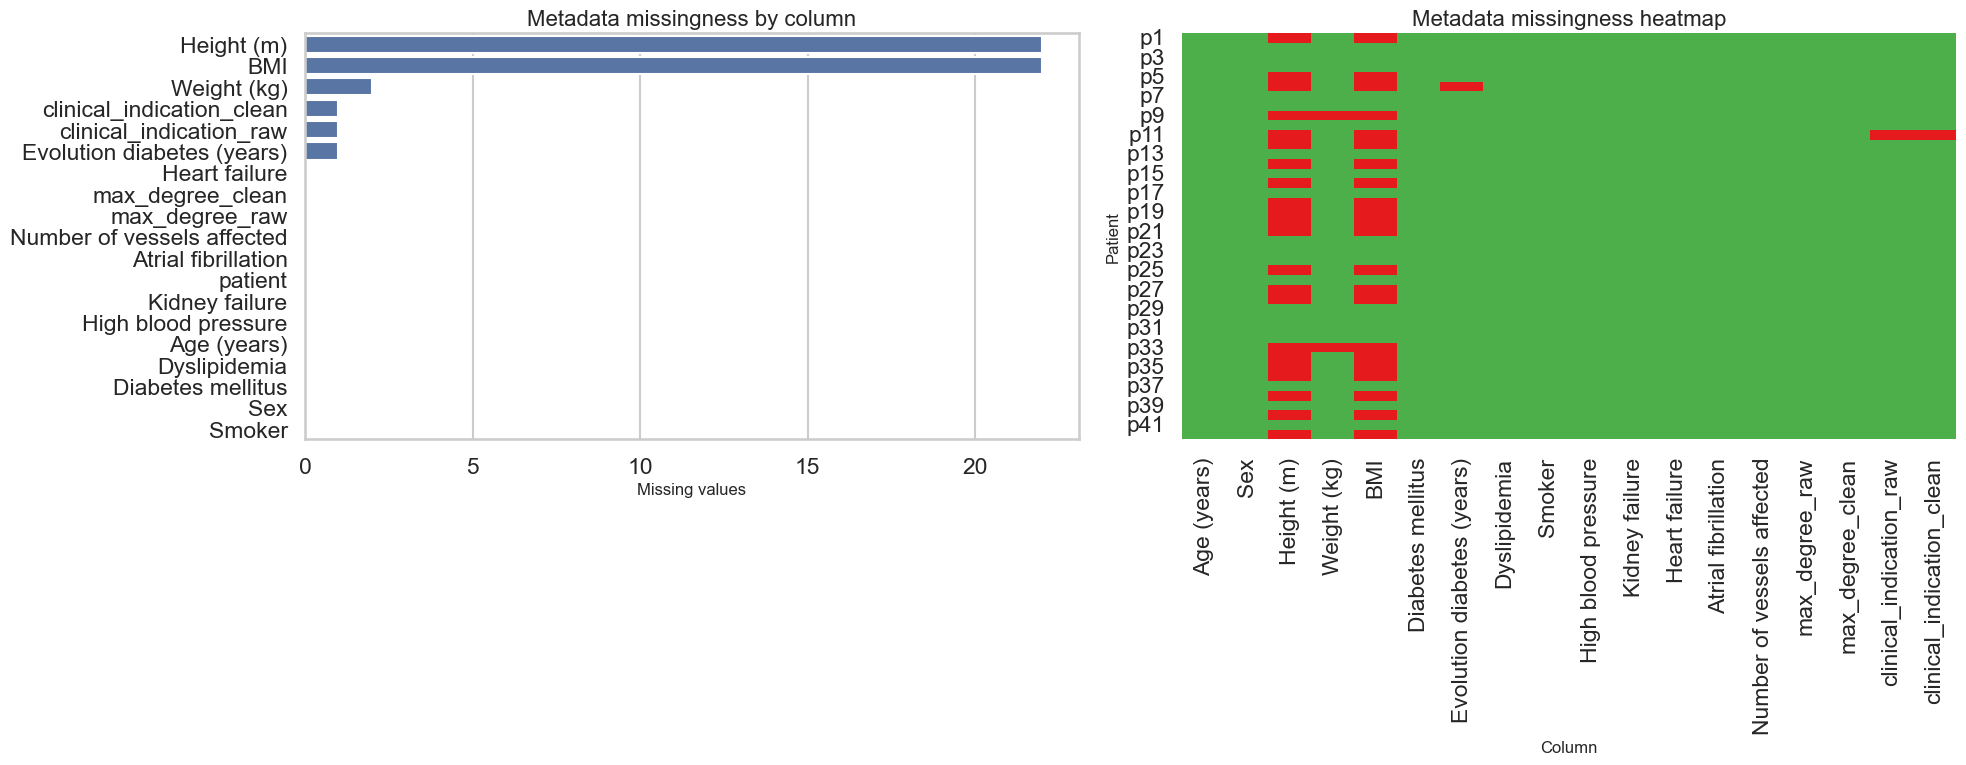

,Maximum degree raw labels,Maximum degree cleaned,Clinical indication raw labels,Clinical indication cleaned
20-50%,8,8,0,0
70%+,0,28,0,0
< 20%,1,0,0,0
<20%,5,6,0,0
> 70%,13,0,0,0
>70%,15,0,0,0
Non-ST segment elevation acute coronary syndrome,0,0,26,0
Non-ST-segment Elevation Acute Coronary Syndrome,0,0,1,0
Non-ST-segment elevation acute coronary syndrome,0,0,0,27
ST segment Elevation Acute Coronary Syndrome,0,0,1,0


In [10]:
metadata_view = patient_df[
    [
        "patient",
        "Age (years)",
        "Sex",
        "Height (m)",
        "Weight (kg)",
        "BMI",
        "Diabetes mellitus",
        "Evolution diabetes (years)",
        "Dyslipidemia",
        "Smoker",
        "High blood pressure",
        "Kidney failure",
        "Heart failure",
        "Atrial fibrillation",
        "Number of vessels affected",
        "max_degree_raw",
        "max_degree_clean",
        "clinical_indication_raw",
        "clinical_indication_clean",
    ]
].copy()

missing_summary = metadata_view.isna().sum().sort_values(ascending=False).rename_axis("column").reset_index(name="missing_count")
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(data=missing_summary, x="missing_count", y="column", ax=axes[0], color="#4c72b0")
axes[0].set_title("Metadata missingness by column")
axes[0].set_xlabel("Missing values")
axes[0].set_ylabel("")

sns.heatmap(metadata_view.set_index("patient").isna(), cmap=ListedColormap(["#4daf4a", "#e41a1c"]), cbar=False, ax=axes[1])
axes[1].set_title("Metadata missingness heatmap")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Patient")

plt.tight_layout()
plt.show()

raw_vs_clean = pd.DataFrame(
    {
        "Maximum degree raw labels": patient_df["max_degree_raw"].value_counts(dropna=False),
        "Maximum degree cleaned": patient_df["max_degree_clean"].value_counts(dropna=False),
        "Clinical indication raw labels": patient_df["clinical_indication_raw"].value_counts(dropna=False),
        "Clinical indication cleaned": patient_df["clinical_indication_clean"].value_counts(dropna=False),
    }
).fillna(0).astype(int)
raw_vs_clean


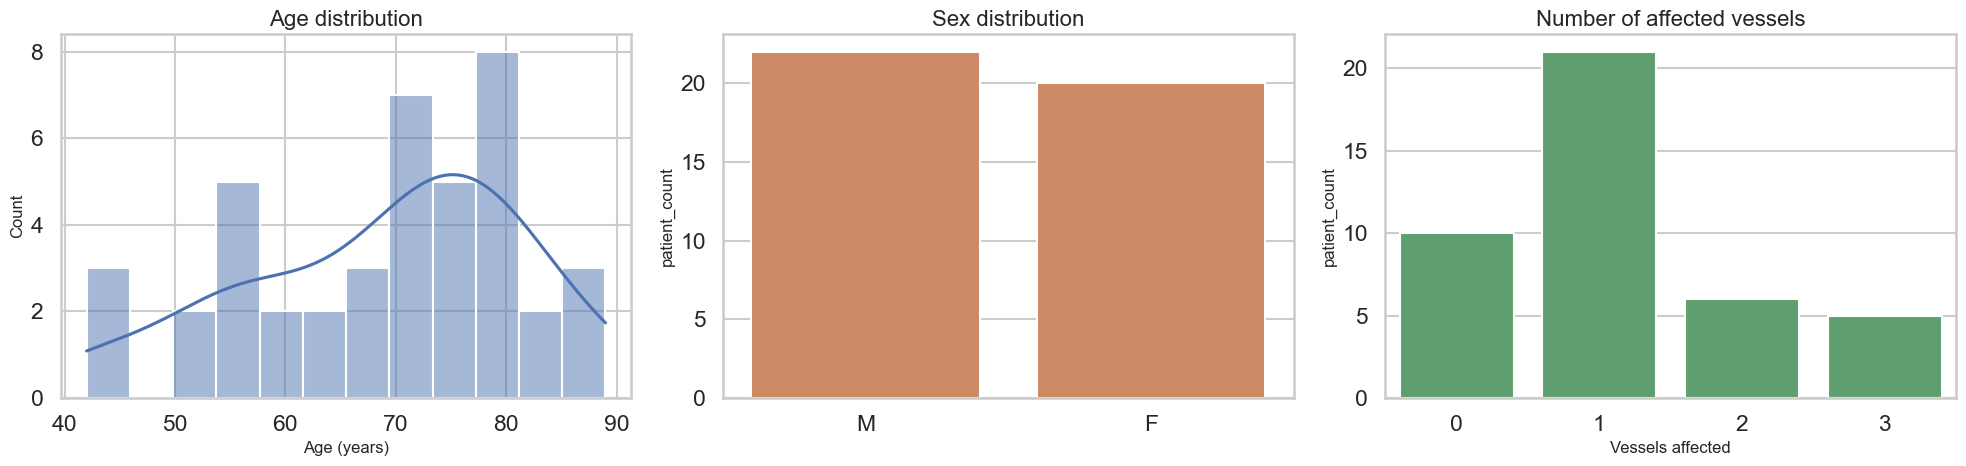

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.histplot(data=patient_df, x="Age (years)", bins=12, kde=True, ax=axes[0], color="#4c72b0")
axes[0].set_title("Age distribution")

sex_counts = patient_df["Sex"].value_counts().rename_axis("Sex").reset_index(name="patient_count")
sns.barplot(data=sex_counts, x="Sex", y="patient_count", ax=axes[1], color="#dd8452")
axes[1].set_title("Sex distribution")
axes[1].set_xlabel("")

vessel_counts = (
    patient_df["Number of vessels affected"]
    .value_counts()
    .rename_axis("vessels_affected")
    .reset_index(name="patient_count")
    .sort_values("vessels_affected")
)
sns.barplot(data=vessel_counts, x="vessels_affected", y="patient_count", ax=axes[2], color="#55a868")
axes[2].set_title("Number of affected vessels")
axes[2].set_xlabel("Vessels affected")

plt.tight_layout()
plt.show()


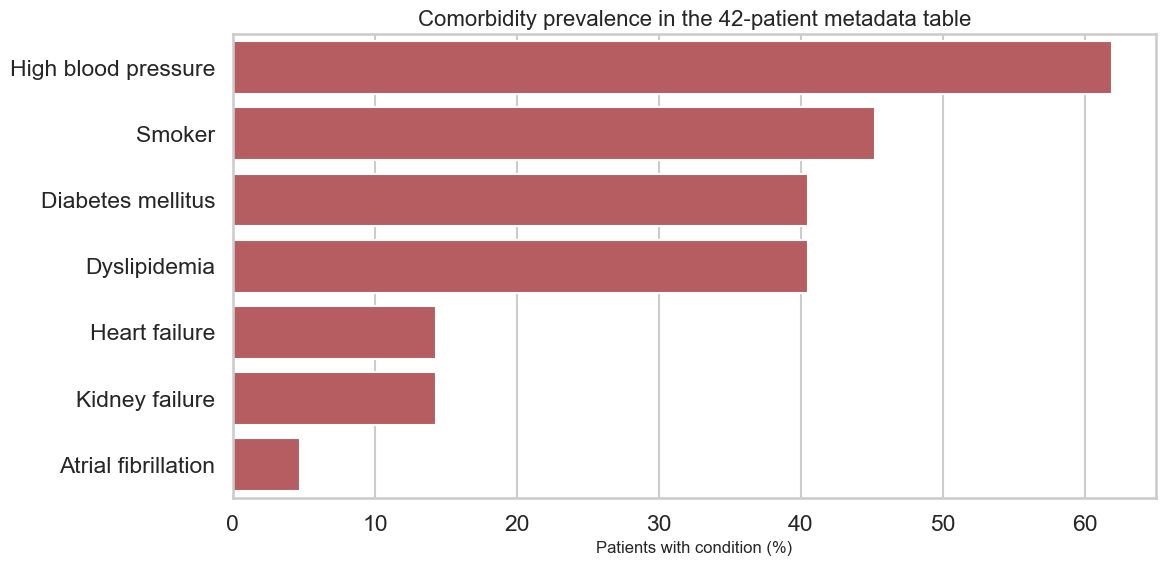

,comorbidity,prevalence,prevalence_pct
4,High blood pressure,0.619048,61.904762
6,Smoker,0.452381,45.238095
1,Diabetes mellitus,0.404762,40.476190
2,Dyslipidemia,0.404762,40.476190
3,Heart failure,0.142857,14.285714
5,Kidney failure,0.142857,14.285714
0,Atrial fibrillation,0.047619,4.761905


In [12]:
comorbidity_long = (
    patient_df[["patient"] + BINARY_COLUMNS]
    .melt(id_vars="patient", var_name="comorbidity", value_name="flag")
    .assign(flag=lambda frame: frame["flag"].fillna(0).astype(int))
)
comorbidity_summary = (
    comorbidity_long.groupby("comorbidity", as_index=False)["flag"].mean()
    .rename(columns={"flag": "prevalence"})
    .sort_values("prevalence", ascending=False)
)
comorbidity_summary["prevalence_pct"] = 100 * comorbidity_summary["prevalence"]

sns.barplot(data=comorbidity_summary, x="prevalence_pct", y="comorbidity", color="#c44e52")
plt.title("Comorbidity prevalence in the 42-patient metadata table")
plt.xlabel("Patients with condition (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

comorbidity_summary


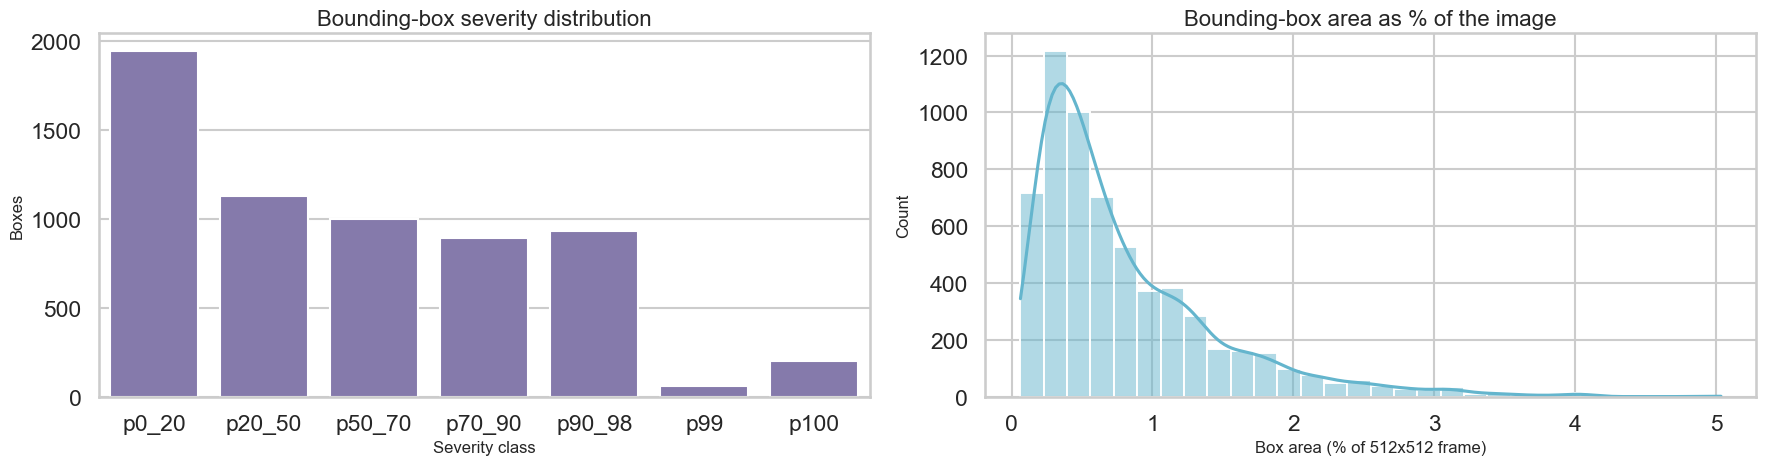

93.5% of CADICA boxes are smaller than 2% of the image area.


,count,mean,std,min,25%,50%,75%,90%,95%,max
width,6161.0,46.048531,24.769150,10.000000,27.000000,41.000000,58.000000,81.000000,97.000000,162.0000
height,6161.0,44.454634,23.205251,11.000000,27.000000,39.000000,56.000000,77.000000,89.000000,181.0000
area_px,6161.0,2136.026944,1784.945499,165.000000,900.000000,1540.000000,2856.000000,4536.000000,5772.000000,13200.0000
area_pct,6161.0,0.814830,0.680903,0.062943,0.343323,0.587463,1.089478,1.730347,2.201843,5.0354


In [13]:
bbox_df["severity_class"] = pd.Categorical(bbox_df["severity_class"], categories=["p0_20", "p20_50", "p50_70", "p70_90", "p90_98", "p99", "p100"], ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

severity_counts = bbox_df["severity_class"].value_counts().rename_axis("severity_class").reset_index(name="box_count")
severity_counts = severity_counts.sort_values("severity_class")
sns.barplot(data=severity_counts, x="severity_class", y="box_count", ax=axes[0], color="#8172b3")
axes[0].set_title("Bounding-box severity distribution")
axes[0].set_xlabel("Severity class")
axes[0].set_ylabel("Boxes")

sns.histplot(data=bbox_df, x="area_pct", bins=30, kde=True, ax=axes[1], color="#64b5cd")
axes[1].set_title("Bounding-box area as % of the image")
axes[1].set_xlabel("Box area (% of 512x512 frame)")

plt.tight_layout()
plt.show()

small_box_share = (bbox_df["area_pct"] < 2).mean() * 100
print(f"{small_box_share:.1f}% of CADICA boxes are smaller than 2% of the image area.")

bbox_df[["width", "height", "area_px", "area_pct"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).T


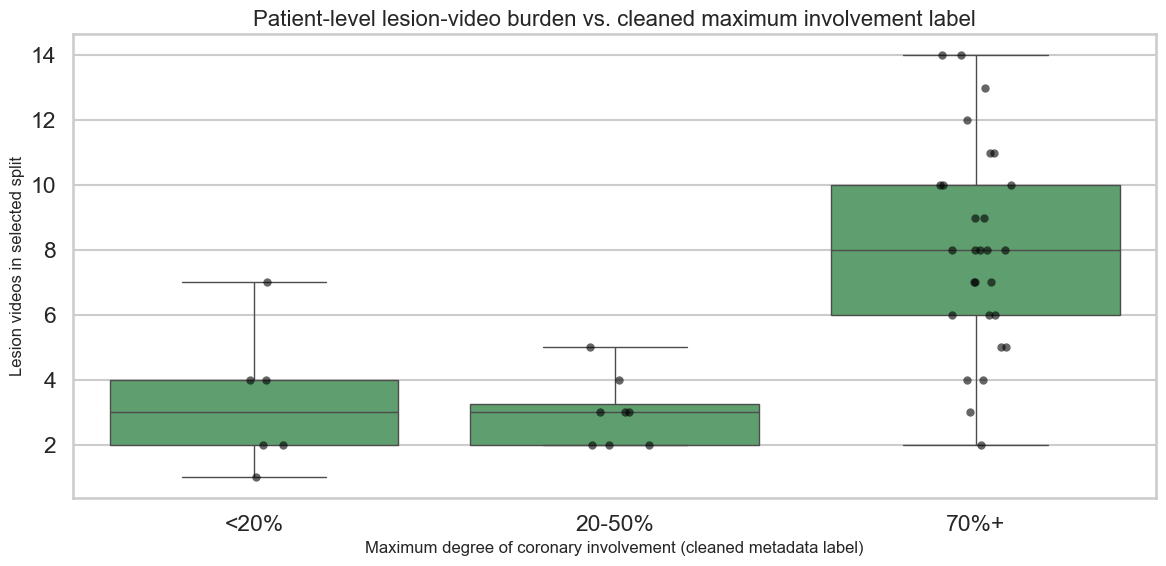

In [14]:
patient_burden_df = (
    patient_df[["patient", "selected_lesion_video_count", "max_degree_clean"]]
    .dropna(subset=["max_degree_clean"])
    .copy()
)

degree_order_for_plot = [degree for degree in ["<20%", "20-50%", "70%+"] if degree in patient_burden_df["max_degree_clean"].unique()]
sns.boxplot(
    data=patient_burden_df,
    x="max_degree_clean",
    y="selected_lesion_video_count",
    order=degree_order_for_plot,
    color="#55a868",
)
sns.stripplot(
    data=patient_burden_df,
    x="max_degree_clean",
    y="selected_lesion_video_count",
    order=degree_order_for_plot,
    color="black",
    size=6,
    alpha=0.6,
)
plt.title("Patient-level lesion-video burden vs. cleaned maximum involvement label")
plt.xlabel("Maximum degree of coronary involvement (cleaned metadata label)")
plt.ylabel("Lesion videos in selected split")
plt.tight_layout()
plt.show()


            ## Leakage And Safety Checks

            CADICA is especially easy to leak if frames or videos are split independently:
            - each patient contributes multiple videos
            - lesion and non-lesion videos often coexist within the same patient
            - selected and nonselected videos also coexist for most patients
            - many patients appear in more than one projection group

            That means a frame-level or video-level split would almost certainly let the model see the same patient anatomy in train and evaluation. The checks below quantify that risk and verify that the folder structure itself is internally consistent.
            


In [15]:
leakage_summary = pd.DataFrame(
    [
        {
            "risk_signal": "Patients with both lesion and non-lesion selected videos",
            "value": int(patient_df["has_both_lesion_and_nonlesion_selected"].sum()),
            "total": len(patient_df),
            "share_pct": 100 * patient_df["has_both_lesion_and_nonlesion_selected"].mean(),
        },
        {
            "risk_signal": "Patients with both selected and nonselected videos",
            "value": int(patient_df["has_selected_and_nonselected"].sum()),
            "total": len(patient_df),
            "share_pct": 100 * patient_df["has_selected_and_nonselected"].mean(),
        },
        {
            "risk_signal": "Patients represented in 2 or 3 projection groups",
            "value": int((patient_df["projection_group_count"] >= 2).sum()),
            "total": len(patient_df),
            "share_pct": 100 * (patient_df["projection_group_count"] >= 2).mean(),
        },
        {
            "risk_signal": "Patients with more than one selected video",
            "value": int((patient_df["selected_video_count"] > 1).sum()),
            "total": len(patient_df),
            "share_pct": 100 * (patient_df["selected_video_count"] > 1).mean(),
        },
    ]
)
leakage_summary


,risk_signal,value,total,share_pct
0,Patients with both lesion and non-lesion selec...,32,42,76.190476
1,Patients with both selected and nonselected vi...,36,42,85.714286
2,Patients represented in 2 or 3 projection groups,40,42,95.238095
3,Patients with more than one selected video,42,42,100.000000


# fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(data=patient_df, x="selected_video_count", bins=15, ax=axes[0], color="#4c72b0")
axes[0].set_title("Selected videos per patient")
axes[0].set_xlabel("Selected videos")

sns.countplot(
    data=patient_df.assign(projection_group_bucket=np.where(patient_df["projection_group_count"] >= 2, "2-3 groups", "0-1 group")),
    x="projection_group_bucket",
    color="#dd8452",
    ax=axes[1],
)
axes[1].set_title("Projection-group overlap across patients")
axes[1].set_xlabel("")
axes[1].set_ylabel("Patients")

plt.tight_layout()
plt.show()


In [16]:
duplicate_df if not duplicate_df.empty else pd.DataFrame(
    [{"md5": None, "occurrences": 0, "unique_videos": 0, "unique_patients": 0, "frame_paths": "No exact duplicate selected keyframes found."}]
)


,md5,occurrences,unique_videos,unique_patients,frame_paths
0,bdce3d8f1368511a8c010eac3eb75bab,2,1,1,/Users/iwosmura/projects/angio-demo/Angiograph...


In [17]:
consistency_df


,check,status,value,details
0,selected patient folders,pass,42,Expected 42 patient folders in selectedVideos.
1,nonselected patient folders,pass,42,All 42 patient folders exist in nonselectedVid...
2,selected videos,pass,382,Expected 382 selected videos.
3,nonselected videos,pass,286,Expected 286 nonselected videos.
4,lesion videos with ground truth,pass,269,Expected 269 lesion videos with annotation fol...
5,all PNGs are 512x512,pass,31500,"All 31,500 PNG files were checked via the PNG ..."
6,patient ids are contiguous,pass,p1-p42,Selected split contains exactly p1 through p42.
7,ground truth only appears in lesion videos,pass,269,Every lesion video has a groundtruth directory...
8,ground truth frames are a subset of selected f...,pass,3996,Verified during table construction for every l...
9,selected/nonselected video ids overlap within ...,pass,0,No patient reuses the same v-id in both select...


            ## Practical Conclusion

            The local CADICA copy looks structurally sound for EDA and downstream training preparation:
            - counts are internally consistent
            - all PNG frames are 512x512
            - lesion-video lists, selected-frame lists, and ground-truth folders agree
            - there is no selected/nonselected video-id collision inside the same patient

            The **main safety concern is leakage, not broken files**. Because CADICA is patient-indexed and each patient often appears across multiple videos, lesion states, and projection groups, any modeling split should be done at the **patient level**. That matches the existing repo guidance in `models/yolov8-stenosis/YOLOv8-stenosis/scripts/prepare_split.py`, which explicitly groups all CADICA frames from the same patient into one split.

            Two data-quality notes are worth keeping in mind:
            - `CADICAprojections.json` does not cover all selected videos, so projection-aware analyses should treat the missing 16 mappings explicitly.
            - metadata categories are not fully normalized, so text fields such as clinical indication and maximum involvement should be cleaned before serious grouped modeling or reporting.
            


In [18]:
result = {
    "patients": int(patient_df["patient"].nunique()),
    "selected_videos": int((video_df["split_name"] == "selected").sum()),
    "nonselected_videos": int((video_df["split_name"] == "nonselected").sum()),
    "total_png_frames": int(video_df["frame_count"].sum()),
    "lesion_videos": int(video_df["lesion_flag"].sum()),
    "annotated_frames": int(bbox_df["frame_id"].nunique()),
    "bounding_boxes": int(len(bbox_df)),
    "patients_with_both_lesion_and_nonlesion_selected": int(patient_df["has_both_lesion_and_nonlesion_selected"].sum()),
    "patients_with_selected_and_nonselected": int(patient_df["has_selected_and_nonselected"].sum()),
    "patients_in_2_or_3_projection_groups": int((patient_df["projection_group_count"] >= 2).sum()),
    "duplicate_keyframe_groups": int(len(duplicate_df)),
}
result


{'patients': 42,
 'selected_videos': 382,
 'nonselected_videos': 286,
 'total_png_frames': 31500,
 'lesion_videos': 269,
 'annotated_frames': 3996,
 'bounding_boxes': 6161,
 'patients_with_both_lesion_and_nonlesion_selected': 32,
 'patients_with_selected_and_nonselected': 36,
 'patients_in_2_or_3_projection_groups': 40,
 'duplicate_keyframe_groups': 1}

            ## Next Steps

            - Use `patient_df`, `video_df`, `bbox_df`, and `consistency_df` as the source tables for any CADICA preprocessing scripts.
            - If this dataset will feed training, carry the patient-level split rule into every export stage.
            - If projection-aware experiments matter, decide how to treat the 16 videos missing projection labels.
            - If metadata will be modeled directly, normalize the remaining text-label variants first.
            
